In [1]:
from kiwipiepy import Kiwi # 형태소 분석기
from collections import Counter # 단어가 나온 횟수를 셈
from wordcloud import WordCloud # 워드클라우드 생성 도구
import matplotlib.pyplot as plt # 시각화 도구
from PIL import Image
import numpy as np
import pandas as pd

In [2]:
data = pd.read_excel('당근_reviews.xlsx')
data

,Unnamed: 0,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0,97282f9b-d20a-4b39-b6b8-297ac5a6d8ff,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,서비스제공/홍보 신고해도 조치안함. 한달동안 10번은 신고했다.,1,1,25.45.0,2025-11-09 07:07:02,NaN,NaT,25.45.0
1,1,d42b726b-58ea-4118-ada9-86a34c1cd819,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,👍👍👍👍👍,5,0,25.44.1,2025-11-08 20:30:43,NaN,NaT,25.44.1
2,2,4541d297-8b4a-453f-96d1-718e296a47c8,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,정보를 알려줘 서조아요,5,0,25.44.1,2025-11-08 19:42:35,NaN,NaT,25.44.1
3,3,77816dbc-45e9-4538-bae4-9022bdf0d2d3,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,지도가불편 확대기능이 너무떨어져요,1,0,25.45.0,2025-11-08 18:21:02,NaN,NaT,25.45.0
4,4,95ff1a0e-8182-480b-ae7f-cda4925e7a1a,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,문제있음 스트레스많음 해킹인지오류인지버그인지비정상적인것들있음 택배주문시물품이바껴서옴,3,2,25.45.0,2025-11-08 16:00:37,NaN,NaT,25.45.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11551,11551,3d3fc932-8d3c-49c3-a175-59f0b3dcd354,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,편하고 좋은데... 매너점수가 참 신용할 수 없는 점수라고 생각합니다. 본인한테 안...,3,6,22.50.3,2023-01-01 09:02:28,"정찬누님 안녕하세요. 거래 후기, 매너 평가는 매너온도에 즉시 반영되지 않아요. 대...",2023-01-01 10:36:04,22.50.3
11552,11552,75363731-9bea-41e5-ba28-ecd68ba5bda6,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,만족합니다,5,0,22.50.3,2023-01-01 05:58:51,"김용구님 안녕하세요. 먼저, 시간 내어 소중한 리뷰 남겨주셔서 감사해요. 🥕\n앞으...",2023-01-01 10:27:58,22.50.3
11553,11553,ebf958f5-8a01-4bef-8453-a1780c79c7be,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,정말 유용합니다.,5,0,22.50.3,2023-01-01 01:28:51,하품님 안녕하세요. 당근마켓을 유용하게 이용하고 계신다니 당근마켓 팀에게 힘이 됩니...,2023-01-01 10:27:19,22.50.3
11554,11554,d57f6e4c-f357-400c-a330-7ee7aea8b207,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,너무 좋아요,5,0,22.50.3,2023-01-01 01:09:17,봉봉tv님 안녕하세요. 당근마켓을 아껴주시고 사랑해주셔서 감사해요. 💖\n앞으로도 ...,2023-01-01 10:26:15,22.50.3


In [ ]:
# 평점 3점 이하
data_after_2025 = data[data['at'] > '2025-01-01 00:00:00'] # 2749 / 11556

data_score_less_3 = data[data['score'] <= 3] # 6732 / 11556
data_score_less_3_2025 = data_after_2025[data_after_2025['score'] <= 3] # 2099 / 2749

data_score_more_3 = data[data['score'] > 3] # 4824 / 11556
data_score_more_3_2025 = data_after_2025[data_after_2025['score'] > 3] # 650 / 2749

data_score_more_3_2025

,Unnamed: 0,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
1,1,d42b726b-58ea-4118-ada9-86a34c1cd819,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,👍👍👍👍👍,5,0,25.44.1,2025-11-08 20:30:43,NaN,NaT,25.44.1
2,2,4541d297-8b4a-453f-96d1-718e296a47c8,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,정보를 알려줘 서조아요,5,0,25.44.1,2025-11-08 19:42:35,NaN,NaT,25.44.1
8,8,fe6945ca-69cb-4687-9e19-f99946f5723d,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,편리하다,5,0,25.44.1,2025-11-08 10:17:15,NaN,NaT,25.44.1
9,9,fc10dc6f-0002-4d31-bbee-7323b4741e99,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,더 많은 동네 구입할수 있게 해주세요. 당근 좋아요 많은 물건 보고 싶어요. 범위가...,5,0,25.45.0,2025-11-08 07:59:51,NaN,NaT,25.45.0
10,10,7908a583-218d-4d7d-9674-6c89652b395c,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,핸드폰 해킹당해서 아침에 접속해보니 외부거래유출로 5년정지먹음. 통신사이력 및 요구...,5,0,25.45.0,2025-11-08 07:29:51,"안녕하세요, 당근 팀 입니다.\n먼저, 문의 해결과정에서 불편함과 답답함을 느끼신 ...",2025-10-28 16:21:27,25.45.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2734,2734,e955f365-ab87-4e60-b356-86fee776aed0,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,게시물 예약 설정 기능 있으면 좋을거같아요!,4,0,24.52.1,2025-01-03 07:01:29,NaN,NaT,24.52.1
2737,2737,77880ef4-39ee-427c-949e-9e0206b9e3b7,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,괜찮게 쓰고 있긴 한데요ㅠ 자꾸 누른 적도 없는데 판매하겠다고 제가 올린 특정 게시...,4,1,25.1.0,2025-01-02 23:41:36,이정민님 안녕하세요. 내 게시글이 노출되지 않아 많이 답답하셨을 것 같아요.\n다양...,2025-01-07 15:15:04,25.1.0
2745,2745,4efb8fad-e9d2-430c-9867-58b8e0452958,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,개좋다,5,0,24.51.0,2025-01-01 14:22:36,이민희님 안녕하세요. 당근을 이용해주시고 이렇게 소중한 리뷰까지 남겨주어 너무 감사...,2025-01-07 15:12:23,24.51.0
2746,2746,6c2e5a5d-516e-48d0-9e87-91871e9e2622,Google 사용자,https://play-lh.googleusercontent.com/EGemoI2N...,알바도 거래도 할수있어서 좋았습니다.,5,0,24.52.1,2025-01-01 11:48:15,이민정님 안녕하세요. 당근을 유용하게 이용하고 있다니 당근 팀에게 힘이 돼요. ❤️...,2025-01-07 15:12:07,24.52.1


In [29]:
f = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content.txt', 'w', encoding = 'utf-8')
for review_ in data['content']:
    f.write(review_)
f.close()

# 평점 3점 이하 (날짜 모두)
f2 = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content_score_less_3.txt', 'w', encoding = 'utf-8')
for review_ in data_score_less_3['content']:
    f2.write(review_)
f2.close()

# 평점 3점 이하 (2025년)
f2 = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content_score_less_3_2025.txt', 'w', encoding = 'utf-8')
for review_ in data_score_less_3_2025['content']:
    f2.write(review_)
f2.close()

# 평점 4점 이상 (날짜 모두)
f3 = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content_score_more_3.txt', 'w', encoding = 'utf-8')
for review_ in data_score_more_3['content']:
    f3.write(review_)
f3.close()

# 평점 4점 이상 (2025)
f3 = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content_score_more_3_2025.txt', 'w', encoding = 'utf-8')
for review_ in data_score_more_3_2025['content']:
    f3.write(review_)
f3.close()

In [30]:
f = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content.txt', 'r', encoding='utf-8')
review = f.read()
f.close()
print(len(review))

# 평점 3점 이하 (날짜 모두)
f2 = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content_score_less_3.txt', 'r', encoding='utf-8')
review_score_less_3 = f2.read()
f2.close()
print(len(review_score_less_3))

# 평점 3점 이하 (2025년)
f2 = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content_score_less_3_2025.txt', 'r', encoding='utf-8')
review_score_less_3_2025 = f2.read()
f2.close()
print(len(review_score_less_3_2025))

# 평점 4점 이상 (날짜 모두)
f3 = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content_score_more_3.txt', 'r', encoding='utf-8')
review_score_more_3 = f3.read()
f3.close()
print(len(review_score_more_3))

# 평점 4점 이상 (2025년)
f3 = open('./data/LG_ThinQ_reviews_GooglePlayStore_Content_score_more_3_2025.txt', 'r', encoding='utf-8')
review_score_more_3_2025 = f3.read()
f3.close()
print(len(review_score_more_3_2025))

638228
425347
21613
212881
18062


In [ ]:
# 도구 객체생성
kiwi = Kiwi()

# 토큰화
'''
review
review_score_less_3
review_score_less_3_2025
review_score_more_3
review_score_more_3_2025
'''
token = kiwi.tokenize(review_score_less_3) 
#token

# form: 토큰화 결과
# tag: 품사 태그
# nnp: 고유명사; nng: 일반명사

In [38]:
# 일반명사만 추출 (NNG)
# 리스트명 = [실행문 반복문 조건]
# nng_token = [t.form for t in token if t.tag=='NNG']
nngp_token = [t.form for t in token if t.tag=='NNG' or t.tag=='NNP']

print(len(nngp_token))
#print(nngp_token)

27806


In [39]:
# 2글자 이상의 단어만 추출
nngp_token2 = [t for t in nngp_token if len(t)>=2]
nngp_token2

['식기세척기',
 '플라스틱',
 '모드',
 '다운로드',
 '패치',
 '세부',
 '설정',
 '편리',
 '배송',
 '친절',
 '화질',
 '채널',
 '다양',
 '유지',
 '관리',
 '도움',
 '인덕션',
 '사용',
 '띵큐앱',
 '인덕션',
 '사용',
 '조하',
 '기능',
 '조작',
 '가능',
 '외부',
 '조절',
 '중간',
 '중간',
 '기기',
 '관리법',
 '자가',
 '진단',
 '기능',
 '제픎',
 '사용',
 '편리',
 '세상',
 '편리',
 '기능',
 '제어',
 '사용',
 '휴대폰',
 '오프',
 '작동',
 '에어컨',
 '편리',
 '휴대폰',
 '가전',
 '연결',
 '냉장고',
 '세탁기',
 '공기',
 '청정기',
 '전자',
 '제품',
 '기능',
 '작동',
 '업그레이드',
 '펀리',
 '사용',
 '편리',
 '리모콘',
 '필요',
 '가전',
 '용량',
 '단점',
 '편리',
 '메세지가',
 '컨트럴',
 '가정',
 '전자',
 '기기',
 '세탁기',
 '원격',
 '조종',
 '.좋와요',
 '에너지',
 '모니터링',
 '누진',
 '단계',
 '단계',
 '설정',
 '단계',
 '설정',
 '가능',
 '예상',
 '요금',
 '사용',
 '편리',
 '디바이스',
 '제품',
 '연결',
 '엘지',
 '냉장고',
 '이상',
 '가격',
 '서비스',
 '최고',
 '편리',
 '애니플러스',
 '추가',
 '편리',
 '리모컨',
 '기능',
 '기능',
 '동일',
 '리모컨',
 '접속',
 '핸드폰',
 '공유',
 '만족',
 '감사',
 '포켓',
 '포토',
 '사용',
 '편리',
 '컨트롤',
 '가능',
 '부분',
 '유용',
 '신세계',
 '입장',
 '가전',
 '최고',
 '사용',
 '최근',
 '업데이트',
 '이후',
 '시스템',
 '에어컨',
 '디바이스',
 '전력',
 '사용량',
 '표시',
 '동일',

In [40]:
# 명사의 개수를 세서 많이 나오는 단어를 활용하여 워드클라우드 생성하기
counter = Counter(nngp_token2)
counter

Counter({'편리': 1291,
         '사용': 1251,
         '기능': 580,
         '연결': 529,
         '에어컨': 451,
         '제품': 438,
         '세탁기': 330,
         '가전': 296,
         '스마트': 288,
         '원격': 255,
         '건조기': 251,
         '어플': 250,
         '가능': 243,
         '엘지': 242,
         '확인': 237,
         '유용': 224,
         '제어': 221,
         '최고': 217,
         '시간': 215,
         '설정': 214,
         '등록': 203,
         '공기': 195,
         '진단': 193,
         '만족': 190,
         '업데이트': 185,
         '알림': 180,
         '전원': 176,
         '관리': 171,
         '청정기': 162,
         '작동': 155,
         '상태': 154,
         '세탁': 148,
         '와이파이': 146,
         '감사': 138,
         '기기': 125,
         '리모컨': 123,
         '설치': 123,
         '냉장고': 121,
         '알람': 111,
         '연동': 108,
         '추가': 107,
         '세상': 104,
         '예약': 104,
         '필요': 96,
         '티비': 93,
         '불편': 93,
         '핸드폰': 91,
         '청소기': 89,
         '문제': 87,
         '건

In [41]:
# 상위 100개 단어만 추출
top_100 = counter.most_common(100)
top_100

[('편리', 1291),
 ('사용', 1251),
 ('기능', 580),
 ('연결', 529),
 ('에어컨', 451),
 ('제품', 438),
 ('세탁기', 330),
 ('가전', 296),
 ('스마트', 288),
 ('원격', 255),
 ('건조기', 251),
 ('어플', 250),
 ('가능', 243),
 ('엘지', 242),
 ('확인', 237),
 ('유용', 224),
 ('제어', 221),
 ('최고', 217),
 ('시간', 215),
 ('설정', 214),
 ('등록', 203),
 ('공기', 195),
 ('진단', 193),
 ('만족', 190),
 ('업데이트', 185),
 ('알림', 180),
 ('전원', 176),
 ('관리', 171),
 ('청정기', 162),
 ('작동', 155),
 ('상태', 154),
 ('세탁', 148),
 ('와이파이', 146),
 ('감사', 138),
 ('기기', 125),
 ('리모컨', 123),
 ('설치', 123),
 ('냉장고', 121),
 ('알람', 111),
 ('연동', 108),
 ('추가', 107),
 ('세상', 104),
 ('예약', 104),
 ('필요', 96),
 ('티비', 93),
 ('불편', 93),
 ('핸드폰', 91),
 ('청소기', 89),
 ('문제', 87),
 ('건조', 83),
 ('버튼', 83),
 ('가전제품', 79),
 ('이용', 77),
 ('완료', 76),
 ('청소', 76),
 ('온도', 72),
 ('자동', 72),
 ('처음', 72),
 ('스마트폰', 72),
 ('개선', 70),
 ('모드', 69),
 ('로그인', 69),
 ('로봇', 69),
 ('생각', 69),
 ('조작', 68),
 ('부탁', 67),
 ('코스', 67),
 ('정보', 66),
 ('화면', 66),
 ('빨래', 66),
 ('종료', 65),
 ('정수기', 64),


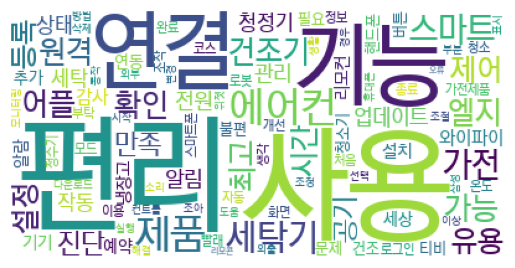

In [42]:
# WordCloud(): 스타일(배경,글꼴), 최대단어수, 마스크이미지 등 옵션을 설정
# generate_from_frequencies(): 미리 정의된 단어의 빈도수를 이용해서 워드클라우드 이미지를 생성

wc = WordCloud(
    font_path='C:/Windows/Fonts/LG PC.ttf', # malgunbd.ttf
    background_color='white'
    # mask=mask
        
).generate_from_frequencies(dict(top_100))

plt.imshow(wc)
plt.axis('off')
plt.show()